# Solidity / spikiness profiling

This notebook measures cell solidity from the same StarDist masks used for fluorescence. Solidity captures how smooth or spiky a cell boundary is: values near `1.0` are smooth and compact, while lower values suggest jagged, branched, or filopodia-rich shapes.


In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "macrophage_analysis").exists():
    raise RuntimeError("Run this notebook from the repository root or notebooks/ directory.")
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

from IPython.display import display

import matplotlib.pyplot as plt
import seaborn as sns

import macrophage_analysis as ma
from macrophage_analysis.analysis.morphology import prepare_morphology_scatter_points
from macrophage_analysis.analysis.morphology_tables import build_morphology_table
from macrophage_analysis.defaults import DEFAULT_SEABORN_THEME

solidity_donors = list(ma.DEFAULT_DONORS)
solidity_conditions = list(ma.DEFAULT_CONDITIONS)
solidity_antibody = "CD206"
solidity_n_tiles = (8, 8)
solidity_max_points_per_group = 1000
solidity_intensity_upper_percentile = 99.0
solidity_area_upper_percentile = 99.0

solidity_donors, solidity_conditions, solidity_antibody


(['D45', 'D47'],
 ['M0',
  'B68KCP2',
  'B75palmFP1',
  'M130227Ni',
  'M130429Np',
  'T12CMNepiP4',
  'T8CMNdermP6'],
 'CD206')

Run this once. It analyzes only CD206 so the morphology pass stays focused and reasonably fast while still keeping the marker you want to compare against solidity.


In [2]:
solidity_results = ma.extract_single_cell_fluorescence(
    donors=solidity_donors,
    conditions=solidity_conditions,
    antibody_order=[solidity_antibody],
    n_tiles=solidity_n_tiles,
)


Analyzing CD206...
Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.


100%|██████████| 64/64 [00:02<00:00, 25.89it/s]


Finished analyzing 14 donor / treatment / antibody combinations.


First, summarize treatment-level morphology shifts per donor relative to that donor's M0. The heatmap now includes Solidity as its own metric.


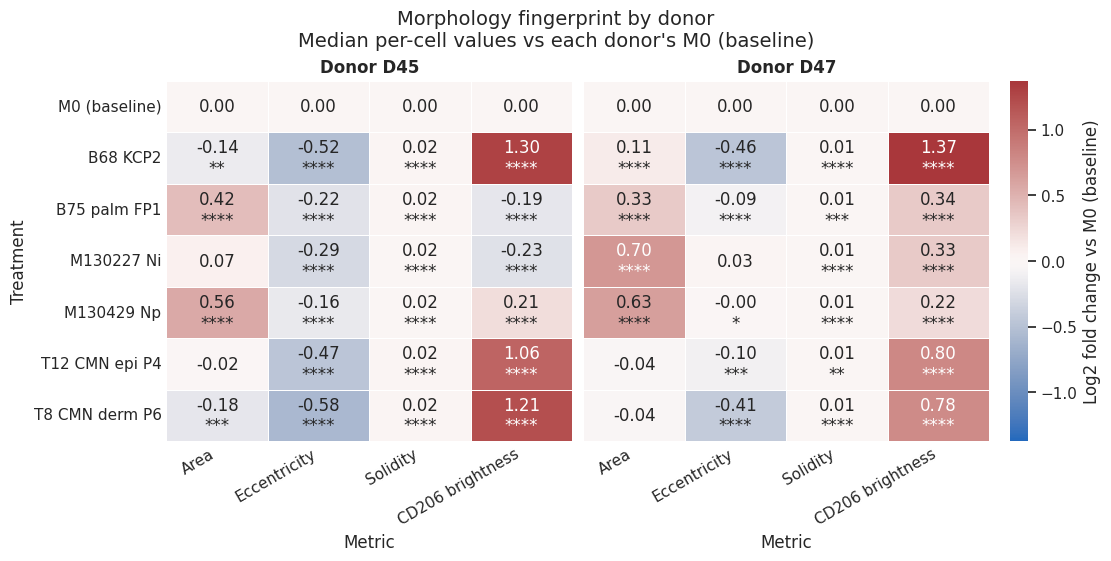

,donor_label,condition_label,log2_fc_area,stars_area,log2_fc_eccentricity,stars_eccentricity,log2_fc_solidity,stars_solidity,log2_fc_cd206_brightness,stars_cd206_brightness
0,Donor D45,M0 (baseline),0.00,baseline,0.000,baseline,0.000,baseline,0.00,baseline
1,Donor D45,B68 KCP2,-0.14,**,-0.524,****,0.023,****,1.30,****
2,Donor D45,B75 palm FP1,0.42,****,-0.216,****,0.022,****,-0.19,****
3,Donor D45,M130227 Ni,0.07,ns,-0.290,****,0.017,****,-0.23,****
4,Donor D45,M130429 Np,0.56,****,-0.162,****,0.017,****,0.21,****
5,Donor D45,T12 CMN epi P4,-0.02,ns,-0.469,****,0.024,****,1.06,****
6,Donor D45,T8 CMN derm P6,-0.18,***,-0.581,****,0.024,****,1.21,****
7,Donor D47,M0 (baseline),0.00,baseline,0.000,baseline,0.000,baseline,0.00,baseline
8,Donor D47,B68 KCP2,0.11,****,-0.461,****,0.015,****,1.37,****
9,Donor D47,B75 palm FP1,0.33,****,-0.093,****,0.006,***,0.34,****


In [3]:
solidity_fold_changes = ma.plot_morphology_heatmap(
    solidity_results,
    antibody=solidity_antibody,
    summary_stat="median",
    per_donor=True,
)

solidity_fold_change_display = solidity_fold_changes[
    [
        "donor_label",
        "condition_label",
        "log2_fc_area",
        "stars_area",
        "log2_fc_eccentricity",
        "stars_eccentricity",
        "log2_fc_solidity",
        "stars_solidity",
        "log2_fc_cd206_brightness",
        "stars_cd206_brightness",
    ]
]

display(
    solidity_fold_change_display.round(
        {
            "log2_fc_area": 2,
            "log2_fc_eccentricity": 3,
            "log2_fc_solidity": 3,
            "log2_fc_cd206_brightness": 2,
        }
    )
)


Then inspect the cell-level relationship directly: CD206 brightness on the X-axis and Solidity on the Y-axis. Faint points are sampled cells; large points are treatment medians.


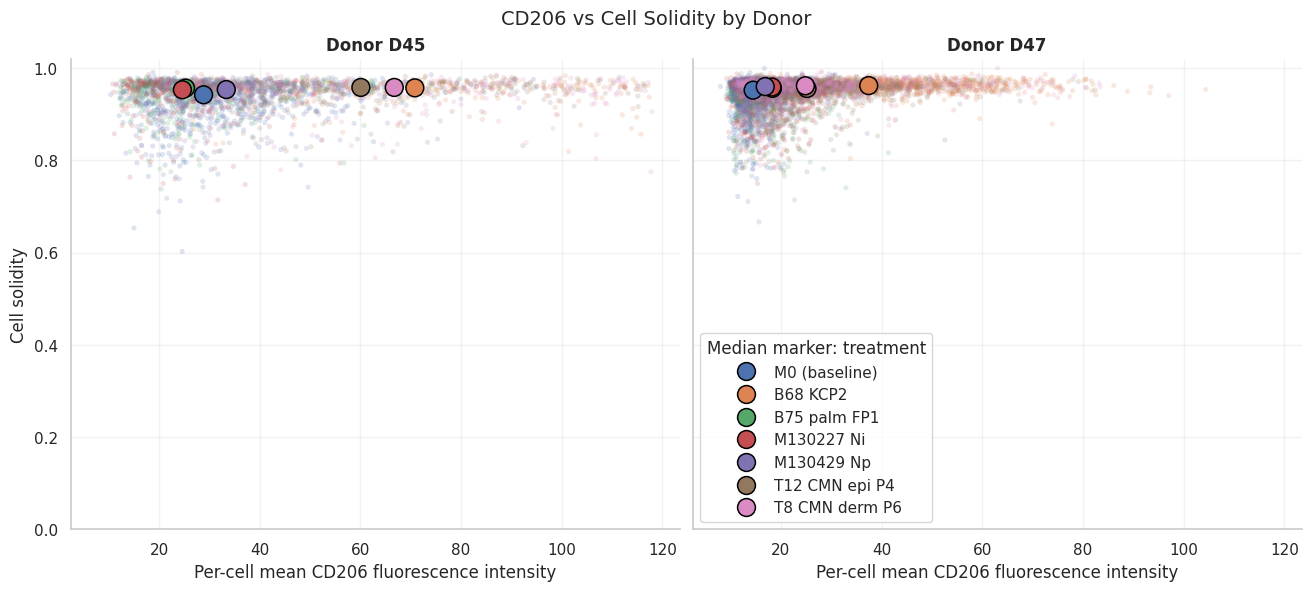

In [4]:
solidity_cells = build_morphology_table(
    solidity_results,
    antibody=solidity_antibody,
)
solidity_plot_df = prepare_morphology_scatter_points(
    solidity_cells,
    max_points_per_group=solidity_max_points_per_group,
    random_seed=7,
    x_column="intensity",
    x_upper_percentile=solidity_intensity_upper_percentile,
    area_upper_percentile=solidity_area_upper_percentile,
)
solidity_summary = ma.build_morphology_summary_table(
    solidity_results,
    antibody=solidity_antibody,
)

sns.set_theme(**DEFAULT_SEABORN_THEME)
donor_label_order = [
    label
    for label in solidity_summary["donor_label"].cat.categories
    if (solidity_plot_df["donor_label"] == label).any()
]
condition_label_order = list(solidity_summary["condition_label"].cat.categories)
fig, axes = plt.subplots(
    1,
    len(donor_label_order),
    figsize=(6.5 * len(donor_label_order), 5.8),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
if len(donor_label_order) == 1:
    axes = [axes]
for ax, donor_label in zip(axes, donor_label_order):
    donor_plot_df = solidity_plot_df.loc[solidity_plot_df["donor_label"] == donor_label]
    donor_summary_df = solidity_summary.loc[solidity_summary["donor_label"] == donor_label]
    sns.scatterplot(
        data=donor_plot_df,
        x="intensity",
        y="solidity",
        hue="condition_label",
        hue_order=condition_label_order,
        alpha=0.18,
        s=14,
        linewidth=0,
        legend=False,
        ax=ax,
    )
    sns.scatterplot(
        data=donor_summary_df,
        x="median_intensity",
        y="median_solidity",
        hue="condition_label",
        hue_order=condition_label_order,
        alpha=1.0,
        s=165,
        linewidth=1.1,
        edgecolor="black",
        legend="brief" if ax is axes[-1] else False,
        ax=ax,
    )
    ax.set_title(str(donor_label), fontsize=12, fontweight="bold")
    ax.set_xlabel(f"Per-cell mean {solidity_antibody} fluorescence intensity")
    ax.set_ylabel("Cell solidity" if ax is axes[0] else "")
    ax.set_ylim(0.0, 1.02)
    ax.grid(alpha=0.25)
    sns.despine(ax=ax)
legend = axes[-1].get_legend()
if legend is not None:
    legend.set_title("Median marker: treatment")
fig.suptitle(f"{solidity_antibody} vs Cell Solidity by Donor", fontsize=14)
plt.show()


Optional QC table: robust medians by donor and condition, now including Solidity.


In [5]:
display(
    solidity_summary.round(
        {
            "median_intensity": 2,
            "median_area": 1,
            "median_eccentricity": 3,
            "median_solidity": 3,
        }
    )
)


,condition,condition_label,donor,donor_label,cell_count,median_intensity,median_area,median_eccentricity,median_solidity
0,M0,M0 (baseline),D45,Donor D45,643,28.83,285.0,0.842,0.942
1,M0,M0 (baseline),D47,Donor D47,1844,14.47,289.0,0.726,0.952
2,B68KCP2,B68 KCP2,D45,Donor D45,311,70.81,258.0,0.586,0.957
3,B68KCP2,B68 KCP2,D47,Donor D47,1047,37.44,312.0,0.528,0.962
4,B75palmFP1,B75 palm FP1,D45,Donor D45,421,25.24,382.0,0.725,0.957
5,B75palmFP1,B75 palm FP1,D47,Donor D47,1875,18.30,364.0,0.681,0.956
6,M130227Ni,M130227 Ni,D45,Donor D45,318,24.63,299.5,0.689,0.953
7,M130227Ni,M130227 Ni,D47,Donor D47,1103,18.22,468.0,0.739,0.959
8,M130429Np,M130429 Np,D45,Donor D45,382,33.34,421.0,0.753,0.954
9,M130429Np,M130429 Np,D47,Donor D47,1460,16.88,448.0,0.725,0.960
